In [5]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from sklearn.model_selection import train_test_split

def process_netflix_file(filepath):
    """
    Process a single Netflix Prize training data file and return a DataFrame
    
    Args:
        filepath (str): Path to the data file
        
    Returns:
        pd.DataFrame: DataFrame with columns [user_id, movie_id, rating, date]
    """
    # Initialize lists to store data
    user_ids = []
    movie_ids = []
    ratings = []
    dates = []
    
    current_movie_id = None
    
    with open(filepath, 'r') as f:
        for line in f:
            # Remove trailing whitespace
            line = line.strip()
            
            # Check if this is a movie ID line (ends with ':')
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
                continue
            
            # Parse rating line
            user_id, rating, date = line.split(',')
            
            # Append to lists
            user_ids.append(int(user_id))
            movie_ids.append(current_movie_id)
            ratings.append(int(rating))
            dates.append(datetime.strptime(date, '%Y-%m-%d'))
    
    # Create DataFrame
    df = pd.DataFrame({
        'user_id': user_ids,
        'movie_id': movie_ids,
        'rating': ratings,
        'date': dates
    })
    
    return df



def create_netflix_dataset(data_files, qualifying_file, min_ratings=10, test_size=0.2, random_state=42):
    """
    Create complete dataset from Netflix Prize data files with train/test split
    
    Args:
        data_files (list): List of paths to training data files
        qualifying_file (str): Path to qualifying set file
        min_ratings (int): Minimum number of ratings per user/movie to include
        test_size (float): Proportion of data to use for testing (default: 0.2)
        random_state (int): Random seed for reproducibility
        
    Returns:
        tuple: (train_df, test_df, qualifying_df) - Training, test and qualifying sets
    """
    # Process training files
    dfs = []
    for filepath in data_files:
        print(f"Processing {filepath}...")
        df = process_netflix_file(filepath)
        dfs.append(df)
    
    # Combine all training DataFrames
    print("Combining training data...")
    full_training_df = pd.concat(dfs, ignore_index=True)
    
    # Sort by date (keeping temporal information, but not using it for splitting)
    full_training_df = full_training_df.sort_values('date')
    
    if min_ratings > 0:
        # Filter users and movies with too few ratings
        user_counts = full_training_df['user_id'].value_counts()
        movie_counts = full_training_df['movie_id'].value_counts()
        
        valid_users = user_counts[user_counts >= min_ratings].index
        valid_movies = movie_counts[movie_counts >= min_ratings].index
        
        # Filter training data
        full_training_df = full_training_df[
            full_training_df['user_id'].isin(valid_users) & 
            full_training_df['movie_id'].isin(valid_movies)
        ]
    
    # Create train/test split
    print("Creating train/test split...")
    train_df, test_df = stratified_rating_split(
        full_training_df, 
        test_size=test_size,
        random_state=random_state
    )
    
    return train_df, test_df

def stratified_rating_split(df, test_size=0.2, random_state=42):
    """
    Split ratings data while maintaining distribution of ratings
    and ensuring all users and movies appear in both sets
    
    Args:
        df (pd.DataFrame): Full ratings DataFrame
        test_size (float): Proportion of data to use for testing
        random_state (int): Random seed for reproducibility
        
    Returns:
        tuple: (train_df, test_df) - Training and test DataFrames
    """
    # Create stratification based on rating values
    train_idx, test_idx = train_test_split(
        np.arange(len(df)),
        test_size=test_size,
        random_state=random_state,
        stratify=df['rating']  # Maintain rating distribution
    )
    
    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()
    
    # Verify all users and movies appear in both sets
    train_users = set(train_df['user_id'].unique())
    train_movies = set(train_df['movie_id'].unique())
    test_users = set(test_df['user_id'].unique())
    test_movies = set(test_df['movie_id'].unique())
    
    # Move some test ratings to train if necessary
    missing_user_mask = ~test_df['user_id'].isin(train_users)
    missing_movie_mask = ~test_df['movie_id'].isin(train_movies)
    
    if missing_user_mask.any() or missing_movie_mask.any():
        move_to_train = test_df[missing_user_mask | missing_movie_mask]
        test_df = test_df[~(missing_user_mask | missing_movie_mask)]
        train_df = pd.concat([train_df, move_to_train], ignore_index=True)
    
    print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")
    print(f"Train ratings distribution:\n{train_df['rating'].value_counts(normalize=True)}")
    print(f"Test ratings distribution:\n{test_df['rating'].value_counts(normalize=True)}")
    
    return train_df, test_df

In [6]:
data_files = [
    'combined_data_1.txt',
    'combined_data_2.txt',
    'combined_data_3.txt',
    'combined_data_4.txt'
]

qualifying_file = 'qualifying.txt'

# Create datasets
training_df, qualifying_df = create_netflix_dataset(
    data_files, 
    qualifying_file,
    min_ratings=5  # Adjust this threshold as needed
)

# Print some statistics
print("\nDataset Statistics:")
print(f"Training ratings: {len(training_df)}")
print(f"Qualifying pairs: {len(qualifying_df)}")
print(f"Unique users in training: {training_df['user_id'].nunique()}")
print(f"Unique movies in training: {training_df['movie_id'].nunique()}")
print(f"Unique users in qualifying: {qualifying_df['user_id'].nunique()}")
print(f"Unique movies in qualifying: {qualifying_df['movie_id'].nunique()}")

Processing combined_data_1.txt...
Processing combined_data_2.txt...
Processing combined_data_3.txt...
Processing combined_data_4.txt...
Combining training data...
Creating train/test split...
Train set size: 80369547, Test set size: 20092381
Train ratings distribution:
rating
4    0.335899
3    0.286749
5    0.230562
2    0.100837
1    0.045953
Name: proportion, dtype: float64
Test ratings distribution:
rating
4    0.335899
3    0.286749
5    0.230562
2    0.100837
1    0.045953
Name: proportion, dtype: float64

Dataset Statistics:
Training ratings: 80369547
Qualifying pairs: 20092381
Unique users in training: 472987
Unique movies in training: 17769
Unique users in qualifying: 469228
Unique movies in qualifying: 17767


In [7]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.sparse import csr_matrix
import gc  # for garbage collection

class MatrixFactorization:
    def __init__(self, n_factors=50, learning_rate=0.005, regularization=0.02, n_epochs=20, batch_size=1000000):
        """
        Optimized Matrix Factorization for large datasets
        
        Args:
            n_factors (int): Number of latent factors (reduced from 100 to 50)
            learning_rate (float): Learning rate for SGD
            regularization (float): Regularization term
            n_epochs (int): Number of training epochs
            batch_size (int): Size of batches for SGD
        """
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        
    def _create_mappings(self, ratings_df):
        """Create efficient user and movie ID mappings"""
        # Use integers for more efficient memory use
        self.user_ids = pd.factorize(ratings_df['user_id'])[1]
        self.movie_ids = pd.factorize(ratings_df['movie_id'])[1]
        
        self.user_map = {id_: i for i, id_ in enumerate(self.user_ids)}
        self.movie_map = {id_: i for i, id_ in enumerate(self.movie_ids)}
        
        return len(self.user_ids), len(self.movie_ids)
    
    def fit(self, ratings_df):
        """Train model with batched SGD"""
        print("Creating user/movie mappings...")
        n_users, n_movies = self._create_mappings(ratings_df)
        
        # Initialize factors with smaller values
        print("Initializing model parameters...")
        self.user_factors = np.random.normal(0, 0.05, (n_users, self.n_factors)).astype(np.float32)
        self.movie_factors = np.random.normal(0, 0.05, (n_movies, self.n_factors)).astype(np.float32)
        
        # Initialize bias terms
        self.user_bias = np.zeros(n_users, dtype=np.float32)
        self.movie_bias = np.zeros(n_movies, dtype=np.float32)
        self.global_bias = float(ratings_df['rating'].mean())
        
        # Convert ratings to mapped indices and numpy array
        print("Preparing training data...")
        ratings_array = np.column_stack((
            ratings_df['user_id'].map(self.user_map),
            ratings_df['movie_id'].map(self.movie_map),
            ratings_df['rating']
        )).astype(np.float32)
        
        del ratings_df  # Free memory
        gc.collect()
        
        print("Starting training...")
        best_rmse = float('inf')
        n_ratings = len(ratings_array)
        n_batches = (n_ratings + self.batch_size - 1) // self.batch_size
        
        for epoch in range(self.n_epochs):
            # Shuffle all ratings
            np.random.shuffle(ratings_array)
            epoch_loss = 0
            
            # Process in batches
            for batch in tqdm(range(n_batches), desc=f'Epoch {epoch + 1}/{self.n_epochs}'):
                start_idx = batch * self.batch_size
                end_idx = min((batch + 1) * self.batch_size, n_ratings)
                batch_ratings = ratings_array[start_idx:end_idx]
                
                # Process each rating in the batch
                u_ids = batch_ratings[:, 0].astype(np.int32)
                m_ids = batch_ratings[:, 1].astype(np.int32)
                ratings = batch_ratings[:, 2]
                
                # Calculate predictions
                predicted = (
                    self.global_bias +
                    self.user_bias[u_ids] +
                    self.movie_bias[m_ids] +
                    np.sum(self.user_factors[u_ids] * self.movie_factors[m_ids], axis=1)
                )
                
                # Calculate errors
                errors = ratings - predicted
                epoch_loss += np.sum(errors ** 2)
                
                # Update biases
                self.user_bias[u_ids] += self.learning_rate * (errors - self.regularization * self.user_bias[u_ids])
                self.movie_bias[m_ids] += self.learning_rate * (errors - self.regularization * self.movie_bias[m_ids])
                
                # Update latent factors
                user_factors_grad = (errors[:, np.newaxis] * self.movie_factors[m_ids] - 
                                   self.regularization * self.user_factors[u_ids])
                movie_factors_grad = (errors[:, np.newaxis] * self.user_factors[u_ids] - 
                                    self.regularization * self.movie_factors[m_ids])
                
                # Update factors with vectorized operations
                np.add.at(self.user_factors, u_ids, self.learning_rate * user_factors_grad)
                np.add.at(self.movie_factors, m_ids, self.learning_rate * movie_factors_grad)
            
            # Calculate RMSE for this epoch
            rmse = np.sqrt(epoch_loss / n_ratings)
            print(f'Epoch {epoch + 1} RMSE: {rmse:.4f}')
            
            # Save best model
            if rmse < best_rmse:
                best_rmse = rmse
                self.best_user_factors = self.user_factors.copy()
                self.best_movie_factors = self.movie_factors.copy()
                self.best_user_bias = self.user_bias.copy()
                self.best_movie_bias = self.movie_bias.copy()
            
            # Reduce learning rate over time
            self.learning_rate *= 0.9
    
    def predict(self, user_id, movie_id):
        """Predict rating for a single user-movie pair"""
        # Handle cold start
        if user_id not in self.user_map or movie_id not in self.movie_map:
            return self.global_bias
        
        u = self.user_map[user_id]
        m = self.movie_map[movie_id]
        
        predicted = (
            self.global_bias +
            self.best_user_bias[u] +
            self.best_movie_bias[m] +
            self.best_user_factors[u] @ self.best_movie_factors[m]
        )
        
        return np.clip(predicted, 1, 5)
    
    def predict_pairs(self, pairs_df, batch_size=100000):
        """Predict ratings for multiple pairs with batching"""
        predictions = []
        
        # Process in batches to avoid memory issues
        for start_idx in range(0, len(pairs_df), batch_size):
            batch_df = pairs_df.iloc[start_idx:start_idx + batch_size]
            batch_preds = [self.predict(row['user_id'], row['movie_id']) 
                         for _, row in batch_df.iterrows()]
            predictions.extend(batch_preds)
            
        return np.array(predictions)

In [8]:
from sklearn.metrics import mean_squared_error

# Initialize and train the model
print("Initializing model...")
mf_model = MatrixFactorization(
    n_factors=50,          # Number of latent factors
    learning_rate=0.005,   # Initial learning rate
    regularization=0.02,   # Regularization parameter
    n_epochs=20,          # Number of training epochs
    batch_size=1000000    # Process 1M ratings at a time
)

# Train the model
print("Training model...")
mf_model.fit(training_df)

# Evaluate on test set
print("Evaluating model...")
test_predictions = mf_model.predict_pairs(qualifying_df)
test_rmse = np.sqrt(mean_squared_error(qualifying_df['rating'], test_predictions))
print(f"Test RMSE: {test_rmse:.4f}")

Initializing model...
Training model...
Creating user/movie mappings...
Initializing model parameters...
Preparing training data...
Starting training...


Epoch 1/20: 100%|██████████| 81/81 [01:18<00:00,  1.03it/s]


Epoch 1 RMSE: 1.0382


Epoch 2/20: 100%|██████████| 81/81 [01:17<00:00,  1.04it/s]


Epoch 2 RMSE: 0.9494


...

Epoch 18 RMSE: 0.8256


Epoch 19/20: 100%|██████████| 81/81 [01:14<00:00,  1.08it/s]


Epoch 19 RMSE: 0.8243


Epoch 20/20: 100%|██████████| 81/81 [01:19<00:00,  1.02it/s]


Epoch 20 RMSE: 0.8231
Evaluating model...
Test RMSE: 0.8453


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
test_mae = mean_absolute_error(qualifying_df['rating'], test_predictions)
print(f"Test MAE: {test_mae:.4f}")

Test MAE: 0.6578


In [10]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

class FastUserBasedCF:
    def __init__(self, k_neighbors=50, min_ratings=20, max_users=50000):
        """
        Optimized User-Based Collaborative Filtering
        
        Args:
            k_neighbors (int): Number of similar users to consider (reduced from 100)
            min_ratings (int): Minimum number of ratings for a user (increased from 5)
            max_users (int): Maximum number of users to consider for similarity calculation
        """
        self.k_neighbors = k_neighbors
        self.min_ratings = min_ratings
        self.max_users = max_users
        
    def fit(self, ratings_df):
        """Train the model using the ratings DataFrame"""
        print("Preprocessing data...")
        # Count ratings per user and movie
        user_counts = ratings_df['user_id'].value_counts()
        movie_counts = ratings_df['movie_id'].value_counts()
        
        # Filter users and movies with enough ratings
        valid_users = user_counts[user_counts >= self.min_ratings].index
        valid_movies = movie_counts[movie_counts >= self.min_ratings].index
        
        # If we have too many users, sample them
        if len(valid_users) > self.max_users:
            valid_users = np.random.choice(valid_users, self.max_users, replace=False)
        
        # Filter the ratings DataFrame
        filtered_df = ratings_df[
            ratings_df['user_id'].isin(valid_users) & 
            ratings_df['movie_id'].isin(valid_movies)
        ]
        
        print("Creating user and movie mappings...")
        # Create mappings
        self.user_ids = pd.factorize(filtered_df['user_id'])[1]
        self.movie_ids = pd.factorize(filtered_df['movie_id'])[1]
        
        self.user_map = {id_: i for i, id_ in enumerate(self.user_ids)}
        self.movie_map = {id_: i for i, id_ in enumerate(self.movie_ids)}
        
        self.n_users = len(self.user_ids)
        self.n_movies = len(self.movie_ids)
        
        print("Creating user-movie matrix...")
        # Convert to sparse matrix
        user_idx = filtered_df['user_id'].map(self.user_map).values
        movie_idx = filtered_df['movie_id'].map(self.movie_map).values
        ratings = filtered_df['rating'].values
        
        self.rating_matrix = csr_matrix(
            (ratings, (user_idx, movie_idx)),
            shape=(self.n_users, self.n_movies)
        )
        
        print("Calculating user means...")
        # Calculate mean ratings
        self.user_means = np.zeros(self.n_users)
        self.user_rating_counts = np.zeros(self.n_users)
        
        for i in range(self.n_users):
            user_ratings = self.rating_matrix[i].data
            if len(user_ratings) > 0:
                self.user_means[i] = user_ratings.mean()
                self.user_rating_counts[i] = len(user_ratings)
        
        print("Calculating similarities...")
        # Calculate similarities in smaller batches
        batch_size = 100  # Reduced batch size
        self.similarities = {}
        
        for i in tqdm(range(0, self.n_users, batch_size)):
            batch_end = min(i + batch_size, self.n_users)
            batch_users = np.arange(i, batch_end)
            
            # Get normalized ratings for batch
            batch_matrix = self.rating_matrix[batch_users].toarray()
            for j, user in enumerate(batch_users):
                batch_matrix[j] = np.where(
                    batch_matrix[j] != 0,
                    batch_matrix[j] - self.user_means[user],
                    0
                )
            
            # Calculate similarities
            batch_sim = cosine_similarity(batch_matrix, self.rating_matrix.toarray())
            
            # Store top k neighbors for each user
            for idx, user in enumerate(batch_users):
                sim_scores = batch_sim[idx]
                # Get top k+1 similar users (including self)
                top_k_idx = np.argpartition(sim_scores, -(self.k_neighbors + 1))[-(self.k_neighbors + 1):]
                # Remove self-similarity
                top_k_idx = top_k_idx[top_k_idx != user][:self.k_neighbors]
                
                self.similarities[user] = {
                    'users': top_k_idx,
                    'scores': sim_scores[top_k_idx]
                }
        
        # Store global mean for cold start
        self.global_mean = ratings.mean()
        print("Training completed!")
    
    def predict(self, user_id, movie_id):
        """Predict rating for a user-movie pair"""
        # Handle cold start
        if user_id not in self.user_map or movie_id not in self.movie_map:
            return self.global_mean
        
        user_idx = self.user_map[user_id]
        movie_idx = self.movie_map[movie_id]
        
        # If user doesn't have enough ratings, return global mean
        if self.user_rating_counts[user_idx] < self.min_ratings:
            return self.global_mean
        
        # Get similar users and their ratings
        sim_users = self.similarities[user_idx]['users']
        sim_scores = self.similarities[user_idx]['scores']
        
        # Get ratings for the movie
        neighbor_ratings = self.rating_matrix[sim_users, movie_idx].toarray().flatten()
        
        # Filter out users who haven't rated
        mask = neighbor_ratings != 0
        neighbor_ratings = neighbor_ratings[mask]
        sim_scores = sim_scores[mask]
        
        if len(neighbor_ratings) == 0:
            return self.user_means[user_idx]
        
        # Calculate weighted average
        weighted_sum = np.sum(neighbor_ratings * sim_scores)
        sim_sum = np.sum(sim_scores)
        
        if sim_sum == 0:
            return self.user_means[user_idx]
        
        predicted = weighted_sum / sim_sum
        return np.clip(predicted, 1, 5)
    
    def predict_pairs(self, pairs_df, batch_size=10000):
        """Predict ratings for multiple pairs"""
        predictions = []
        
        for start_idx in tqdm(range(0, len(pairs_df), batch_size), desc="Making predictions"):
            batch_df = pairs_df.iloc[start_idx:start_idx + batch_size]
            batch_preds = [self.predict(row['user_id'], row['movie_id']) 
                          for _, row in batch_df.iterrows()]
            predictions.extend(batch_preds)
        
        return np.array(predictions)

def train_fast_user_cf(training_df, k_neighbors=50, min_ratings=20, max_users=50000):
    """Train the optimized model"""
    model = FastUserBasedCF(
        k_neighbors=k_neighbors,
        min_ratings=min_ratings,
        max_users=max_users
    )
    model.fit(training_df)
    return model

In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_user_cf_model(train_df, test_df, k_neighbors=50, min_ratings=20, max_users=50000):
    """
    Train and evaluate the Fast User-Based CF model
    
    Args:
        train_df: Training DataFrame with columns [user_id, movie_id, rating, date]
        test_df: Test DataFrame with columns [user_id, movie_id, rating, date]
        k_neighbors: Number of neighbors to use
        min_ratings: Minimum number of ratings per user
        max_users: Maximum number of users to consider
    
    Returns:
        tuple: (model, rmse, mae)
    """
    print("Training model...")
    model = FastUserBasedCF(
        k_neighbors=k_neighbors,
        min_ratings=min_ratings,
        max_users=max_users
    )
    
    # Train the model
    model.fit(train_df)
    
    print("Making predictions on test set...")
    # Get predictions for test set
    test_predictions = model.predict_pairs(test_df)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(test_df['rating'], test_predictions))
    mae = mean_absolute_error(test_df['rating'], test_predictions)
    
    print(f"\nEvaluation Results:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    
    return model, rmse, mae

In [12]:

# Train and evaluate model
model_user_cf, rmse_user_cf, mae_user_cf = evaluate_user_cf_model(
    train_df=training_df,
    test_df=qualifying_df,
    k_neighbors=50,    # Reduced from 100 for memory efficiency
    min_ratings=20,    # Increased from 5 for better predictions
    max_users=50000    # Limit number of users for memory efficiency
)

Training model...
Preprocessing data...
Creating user and movie mappings...
Creating user-movie matrix...
Calculating user means...
Calculating similarities...


100%|██████████| 500/500 [27:15<00:00,  3.27s/it]


Training completed!
Making predictions on test set...


Making predictions: 100%|██████████| 2010/2010 [06:00<00:00,  5.58it/s]



Evaluation Results:
RMSE: 1.0800
MAE: 0.8970


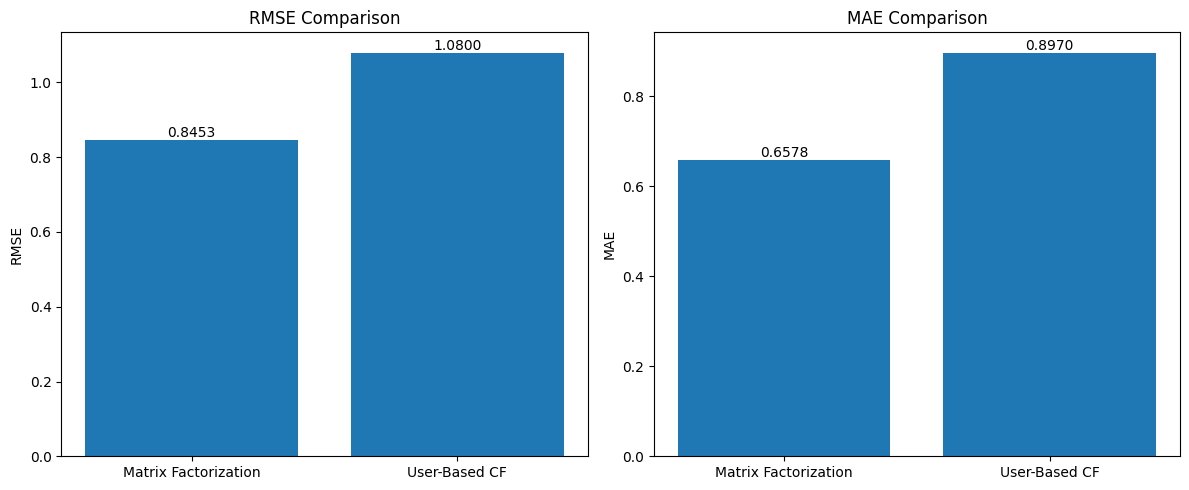


Numeric Comparison:
Matrix Factorization - RMSE: 0.8453, MAE: 0.6578
User-Based CF       - RMSE: 1.0800, MAE: 0.8970


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set figure size
plt.figure(figsize=(12, 5))

# Plot RMSE comparison
plt.subplot(1, 2, 1)
models = ['Matrix Factorization', 'User-Based CF']
rmse_values = [test_rmse, rmse_user_cf]

bars = plt.bar(models, rmse_values)
plt.title('RMSE Comparison')
plt.ylabel('RMSE')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

# Plot MAE comparison
plt.subplot(1, 2, 2)
mae_values = [test_mae, mae_user_cf]

bars = plt.bar(models, mae_values)
plt.title('MAE Comparison')
plt.ylabel('MAE')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom')

# Adjust layout
plt.tight_layout()
plt.show()

# Print numeric comparison
print("\nNumeric Comparison:")
print(f"Matrix Factorization - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}")
print(f"User-Based CF       - RMSE: {rmse_user_cf:.4f}, MAE: {mae_user_cf:.4f}")